<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-3-Holonomic-Mechanics/Untitled149.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Learning Geodesics on a Sphere**
In this notebook we demonstrate how to compute geodesics on a holonomically constrained configuration space using a neural network, without relying on trajectory data. The configuration space is the unit sphere embedded in
$R^3$, defined by a known holonomic constraint.

The goal is to find the energy-minimizing curve (geodesic) connecting two prescribed points on the sphere. Instead of solving the equations analytically, we represent the trajectory with a neural network that enforces the boundary conditions exactly and is trained by minimizing a physics-informed loss based on kinetic energy and constraint satisfaction.



Geodesic distance d(A,B) = 1.5607966595581182
Chosen speed ||v0||      = 1.5607966184616089
RK endpoint error ||q(1)-B|| = 6.121985052232048e-08
Epoch 500/1000 | Loss=1.224e+00 | Eng=1.221e+00 | Con=3.826e-05
Epoch 1000/1000 | Loss=1.217e+00 | Eng=1.213e+00 | Con=3.131e-05


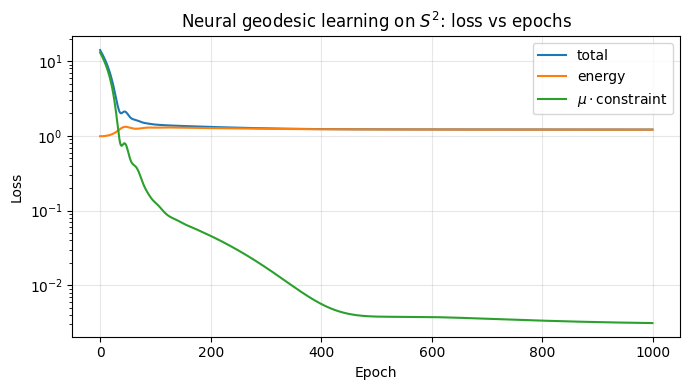

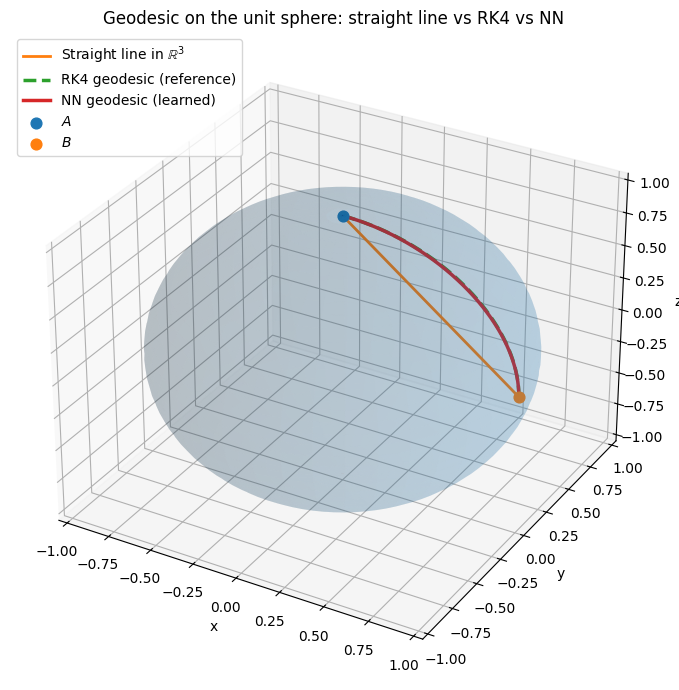

Max NN constraint violation max| ||gamma||^2-1 | = 0.008857548236846924
NN endpoint error ||gamma(1)-B|| = 0.0


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ============================================================
# Geodesic on the unit sphere S^2 between two points A and B
# Compare:
#   (i) Straight line segment in R^3
#   (ii) Runge–Kutta (RK4) integration of constrained geodesic ODE
#   (iii) Neural variational solution (energy + constraint penalty)
#
# Sphere constraint: ||q||=1
# Geodesic dynamics in ambient R^3 (unit mass):
#   q¨ = λ q,  with λ = -||q˙||^2   (follows from differentiating ||q||^2=1 twice)
# So ODE system:
#   q˙ = v
#   v˙ = -(v·v) q
#
# Boundary value A->B (T=1): choose initial velocity along the great circle so q(1)=B.
# ============================================================

np.random.seed(0)
tf.random.set_seed(0)

# ----------------------------
# 1) Choose endpoints A, B on the same (upper) hemisphere
# ----------------------------
A = np.array([0.0, 0.0, 1.0], dtype=np.float32)
B = np.array([1.0, 0.0, 0.01], dtype=np.float32)
A = A / np.linalg.norm(A)
B = B / np.linalg.norm(B)

assert A[2] > 0 and B[2] > 0, "Pick A,B on the same hemisphere (z>0)."

T_final = 1.0

# ----------------------------
# 2) Build RK4 reference geodesic (initial-value problem)
#    Pick v0 so the RK solution hits B at t=1 (great circle).
# ----------------------------
dotAB = float(np.clip(np.dot(A, B), -1.0, 1.0))
dist = float(np.arccos(dotAB))          # geodesic distance on S^2

# Unit tangent at A pointing toward B:
u = B - dotAB * A
u = u / np.linalg.norm(u)

# Constant-speed to traverse distance dist in time T=1:
speed = dist / T_final
v0 = speed * u  # tangent velocity at A

def f_ode(state):
    """state = (q, v) in R^3 x R^3"""
    q = state[:3]
    v = state[3:]
    dq = v
    dv = -(np.dot(v, v)) * q
    return np.hstack([dq, dv])

def rk4_step(state, dt):
    k1 = f_ode(state)
    k2 = f_ode(state + 0.5 * dt * k1)
    k3 = f_ode(state + 0.5 * dt * k2)
    k4 = f_ode(state + dt * k3)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

N_rk = 800
t_rk = np.linspace(0.0, T_final, N_rk, dtype=np.float32)
dt = float(t_rk[1] - t_rk[0])

state = np.hstack([A, v0]).astype(np.float64)
Q_rk = np.zeros((N_rk, 3), dtype=np.float64)

for i in range(N_rk):
    Q_rk[i] = state[:3]
    state = rk4_step(state, dt)

    # mild re-projection (numerical drift control)
    q = state[:3]
    v = state[3:]
    q = q / np.linalg.norm(q)
    v = v - np.dot(q, v) * q  # enforce q·v=0
    state[:3] = q
    state[3:] = v

Q_rk = Q_rk.astype(np.float32)

print("Geodesic distance d(A,B) =", dist)
print("Chosen speed ||v0||      =", float(np.linalg.norm(v0)))
print("RK endpoint error ||q(1)-B|| =", float(np.linalg.norm(Q_rk[-1] - B)))

# ----------------------------
# 3) Neural curve with hard endpoints:
#     gamma_theta(t) = (1-t)A + tB + t(1-t) u_theta(t)
#   Loss = energy + mu * constraint_penalty
#   constraint: ||gamma||^2 - 1 = 0
# ----------------------------
A_tf = tf.constant(A.reshape(1, 3), dtype=tf.float32)
B_tf = tf.constant(B.reshape(1, 3), dtype=tf.float32)

def build_u_net():
    return keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(64, activation="swish"),
        layers.Dense(64, activation="swish"),
        layers.Dense(3)   # u_theta(t) in R^3
    ])

u_net = build_u_net()

def gamma_theta(t):
    # t: (batch,1)
    return (1.0 - t) * A_tf + t * B_tf + t * (1.0 - t) * u_net(t)

# Collocation points
N_col = 300
t_col = np.linspace(0.0, T_final, N_col, dtype=np.float32).reshape(-1, 1)
t_col_tf = tf.constant(t_col)

mu = 100.0
epochs = 1000
lr = 1e-3
opt = keras.optimizers.Adam(learning_rate=lr)

loss_hist, loss_eng_hist, loss_con_hist = [], [], []

for ep in range(epochs):
    # Outer tape for weights, inner tape for time-derivatives
    with tf.GradientTape() as tape_weights:
        with tf.GradientTape() as tape_t:
            tape_t.watch(t_col_tf)
            g = gamma_theta(t_col_tf)  # (N,3)

        dg_dt = tf.squeeze(tape_t.batch_jacobian(g, t_col_tf), axis=-1)  # (N,3)

        # Energy (discrete average of 1/2 ||gamma_dot||^2)
        loss_eng = 0.5 * tf.reduce_mean(tf.reduce_sum(dg_dt**2, axis=1))

        # Constraint penalty: (||g||^2 - 1)^2
        norm2 = tf.reduce_sum(g**2, axis=1)
        loss_con = tf.reduce_mean((norm2 - 1.0)**2)

        loss = loss_eng + mu * loss_con

    grads = tape_weights.gradient(loss, u_net.trainable_variables)
    opt.apply_gradients(zip(grads, u_net.trainable_variables))

    loss_hist.append(float(loss.numpy()))
    loss_eng_hist.append(float(loss_eng.numpy()))
    loss_con_hist.append(float(loss_con.numpy()))

    if (ep + 1) % 500 == 0:
        print(f"Epoch {ep+1}/{epochs} | Loss={loss_hist[-1]:.3e} | "
              f"Eng={loss_eng_hist[-1]:.3e} | Con={loss_con_hist[-1]:.3e}")

# ----------------------------
# 4) Curves for plotting
# ----------------------------
t_plot = np.linspace(0.0, T_final, 600, dtype=np.float32).reshape(-1, 1)
t_plot_tf = tf.constant(t_plot)
G_nn = gamma_theta(t_plot_tf).numpy()   # learned curve (close to sphere)

# Straight line segment in R^3
G_line = (1.0 - t_plot) * A.reshape(1, 3) + t_plot * B.reshape(1, 3)

# ----------------------------
# 5) Plot loss vs epochs
# ----------------------------
plt.figure(figsize=(7, 4))
plt.plot(loss_hist, label="total")
plt.plot(loss_eng_hist, label="energy")
plt.plot([mu * x for x in loss_con_hist], label=r"$\mu\cdot$constraint")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural geodesic learning on $S^2$: loss vs epochs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 6) Plot sphere + curves (line, RK, NN)
# ----------------------------
uu = np.linspace(0, 2*np.pi, 80)
vv = np.linspace(0, np.pi, 40)
UU, VV = np.meshgrid(uu, vv)
Xs = np.cos(UU) * np.sin(VV)
Ys = np.sin(UU) * np.sin(VV)
Zs = np.cos(VV)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(Xs, Ys, Zs, alpha=0.15, linewidth=0)

ax.plot(G_line[:, 0], G_line[:, 1], G_line[:, 2], linewidth=2.0,
        label="Straight line in $\\mathbb{R}^3$")
ax.plot(Q_rk[:, 0], Q_rk[:, 1], Q_rk[:, 2], "--", linewidth=2.5,
        label="RK4 geodesic (reference)")
ax.plot(G_nn[:, 0], G_nn[:, 1], G_nn[:, 2], linewidth=2.5,
        label="NN geodesic (learned)")

ax.scatter([A[0]], [A[1]], [A[2]], s=60, label="$A$")
ax.scatter([B[0]], [B[1]], [B[2]], s=60, label="$B$")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Geodesic on the unit sphere: straight line vs RK4 vs NN")
ax.legend(loc="upper left")

ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_zlim(-1.05, 1.05)

plt.tight_layout()
plt.show()

# ----------------------------
# 7) Numerical checks
# ----------------------------
nn_con_violation = float(np.max(np.abs(np.sum(G_nn**2, axis=1) - 1.0)))
nn_end_err = float(np.linalg.norm(G_nn[-1] - B))

print("Max NN constraint violation max| ||gamma||^2-1 | =", nn_con_violation)
print("NN endpoint error ||gamma(1)-B|| =", nn_end_err)
